# Heterogeneous Analyte Model: Association and Dissociation

This notebook simulates surface response traces for a heterogeneous analyte mixture (multiple analyte subpopulations) and plots association+dissociation traces together.

In [1]:
import numpy as np
from pykingenie.utils.signal_surface import (
    solve_ode_mixture_analyte_association,
    solve_ode_mixture_analyte_dissociation
)
from pykingenie.utils.plotting import plot_traces
from pykingenie.utils.palettes import VIRIDIS
from notebook_helpers import show_plotly_static

## Parameters

- `Fis`: fraction of each analyte subpopulation (must sum to 1)
- `Ris_max`: maximum response contribution for each analyte
- `koffs`: dissociation rate constants for each analyte (1/s)
- `Kds`: equilibrium dissociation constants for each analyte (μM)

`C_TOT` is the total analyte concentration (μM), and concentrations are log-spaced.
The plotted response is the sum of all analyte-specific responses.

In [2]:
# Two analyte subpopulations with different kinetics
Fis = np.array([0.7, 0.3])
Ris_max = np.array([1.0, 1.0])
koffs = np.array([0.01, 0.1])
Kds = np.array([0.1, 1.0])

if not np.isclose(np.sum(Fis), 1.0):
    raise ValueError("Fis must sum to 1.")

In [3]:
concentrations = np.logspace(-2, 1, 6)  # Total analyte concentration in micromolar
t_assoc = np.linspace(0, 300, 400)
t_disso = np.linspace(0, 300, 400)

colors = [VIRIDIS[int(i)] for i in np.linspace(0, len(VIRIDIS) - 1, len(concentrations))]

In [4]:
combined_xs, combined_ys, legends = [], [], []

for conc in concentrations:
    # Association: response of each analyte over time (shape: n_analytes x n_time)
    assoc_components = solve_ode_mixture_analyte_association(
        t=t_assoc,
        Ris0=np.zeros_like(Fis),
        C_TOT=conc,
        Fis=Fis,
        Ris_max=Ris_max,
        koffs=koffs,
        Kds=Kds
    )
    y_assoc = np.sum(assoc_components, axis=0)

    # Dissociation starts from end-of-association component responses
    disso_components = solve_ode_mixture_analyte_dissociation(
        t=t_disso,
        Ris0=assoc_components[:, -1], 
        koffs=koffs
    )
    y_disso = np.sum(disso_components, axis=0)

    combined_xs.append([t_assoc, t_disso + t_assoc[-1]])
    combined_ys.append([y_assoc, y_disso])
    legends.append(f"{conc:.3g} μM")

show = [True] * len(concentrations)

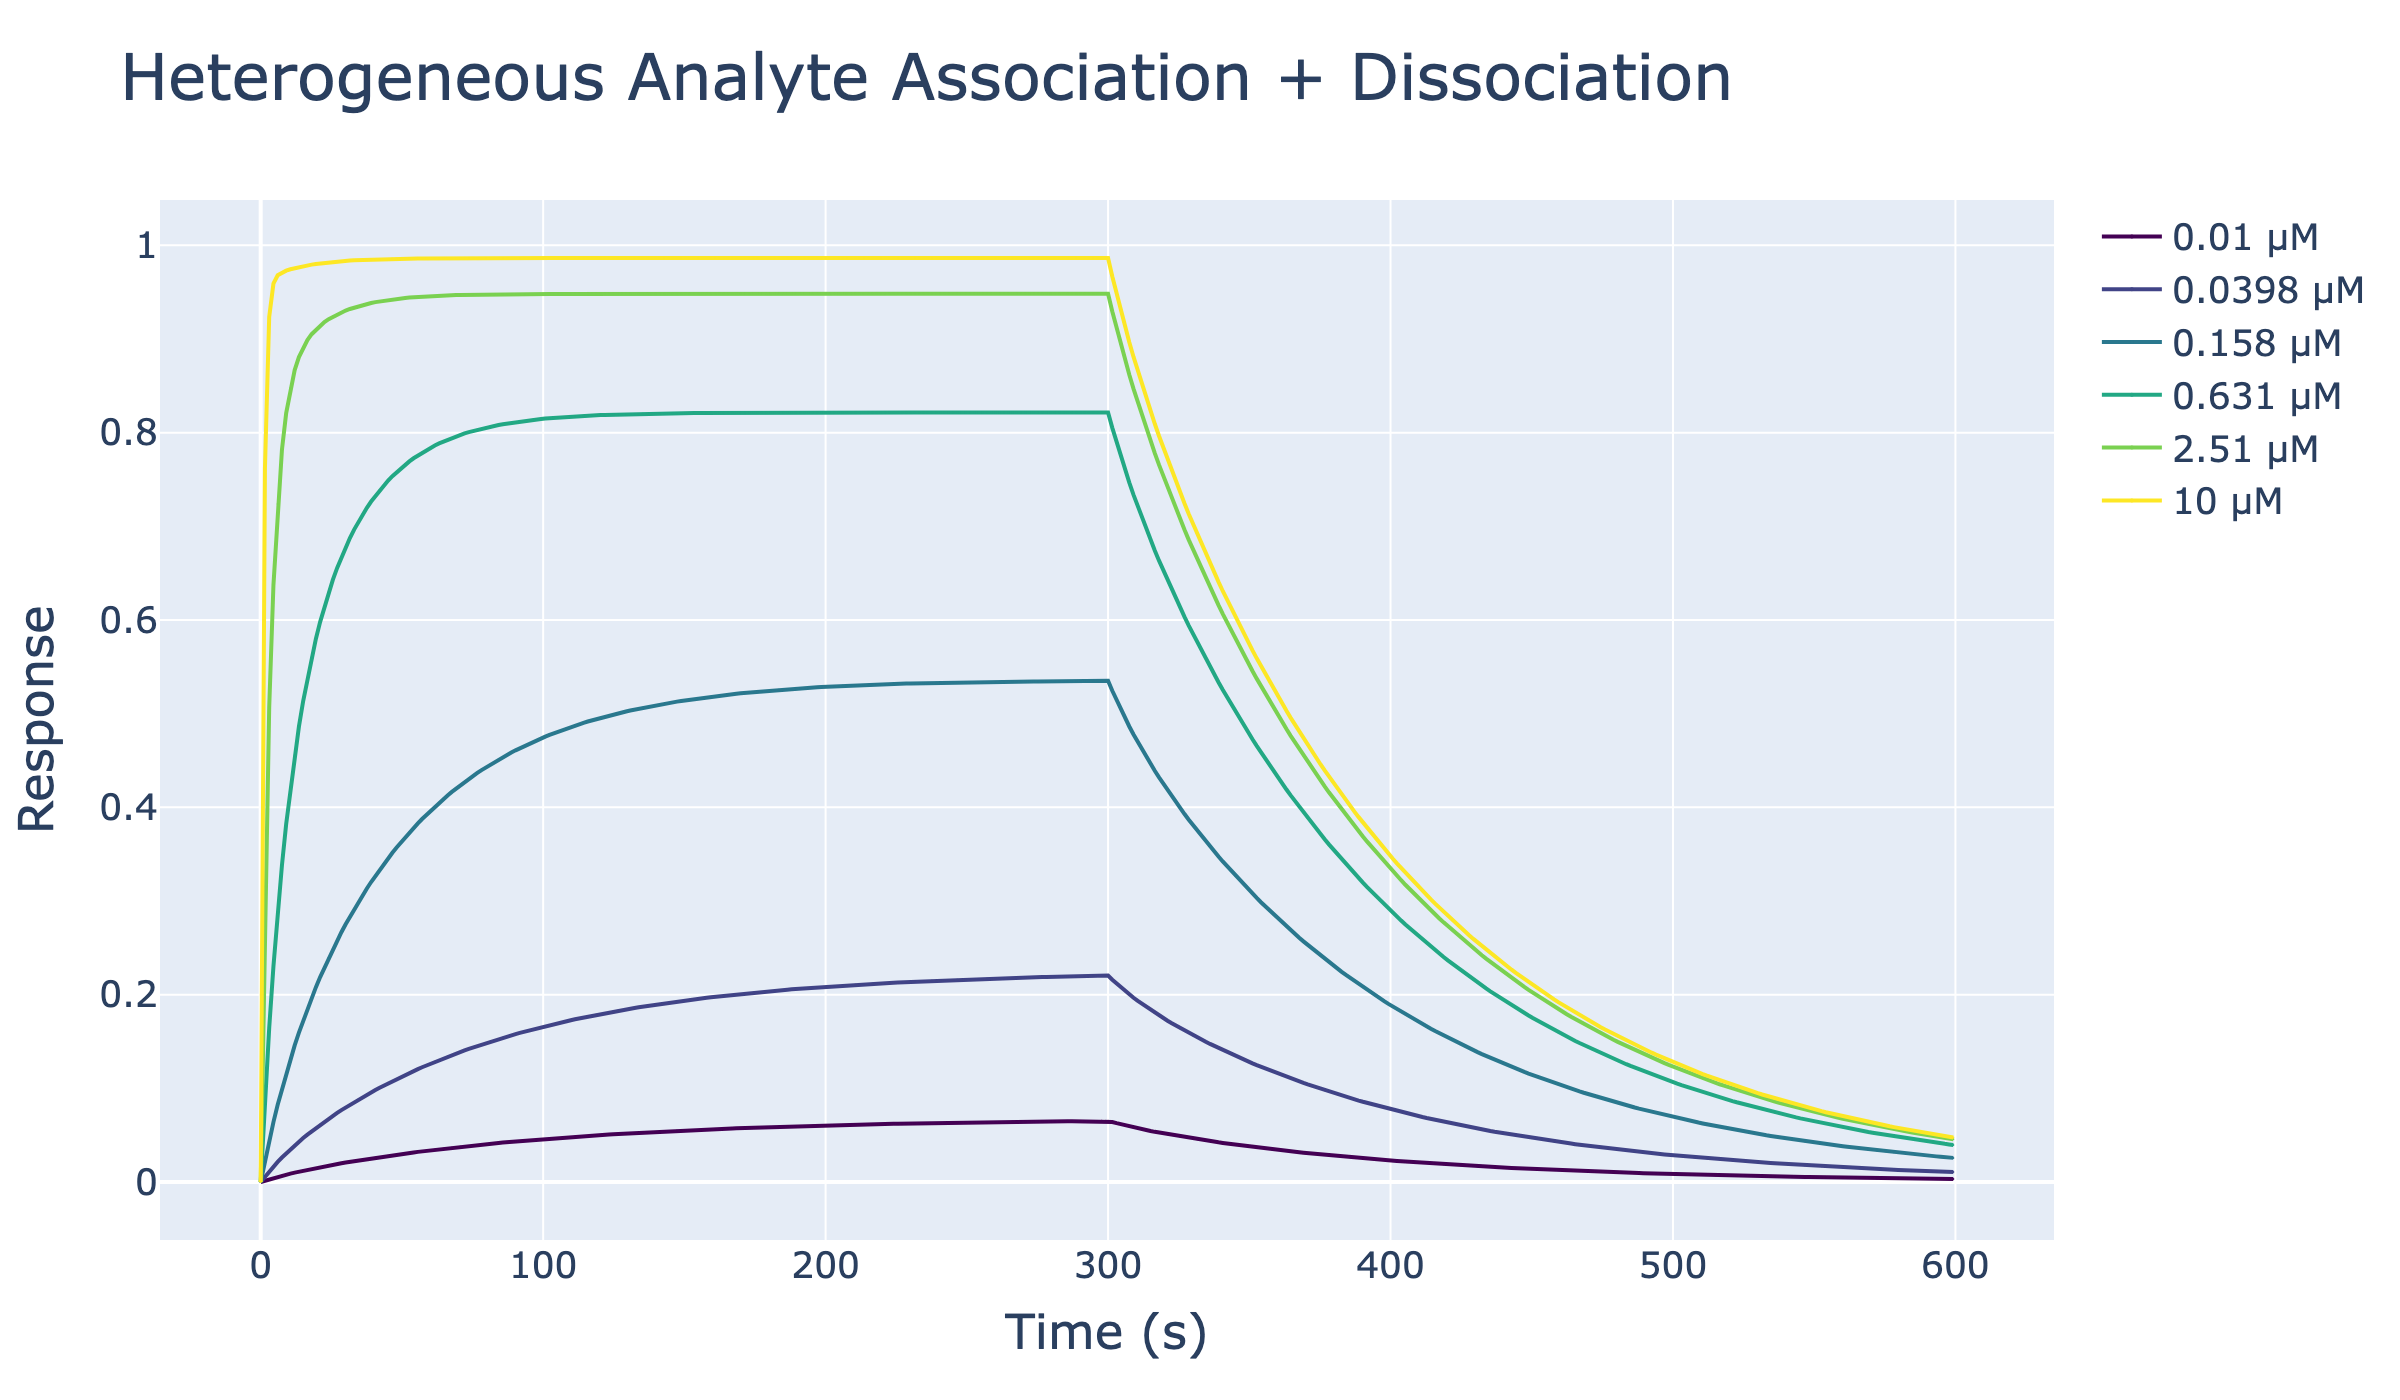

In [5]:
fig = plot_traces(
    xs=combined_xs,
    ys=combined_ys,
    legends=legends,
    colors=colors,
    show=show,
    marker_size=1,
    line_width=2,
)

fig.update_layout(
    title={"text": "Heterogeneous Analyte Association + Dissociation", "font": {"size": 32}},
    xaxis_title="Time (s)",
    yaxis_title="Response",
    font={"size": 20},
    legend={"font": {"size": 18}},
)
fig.update_xaxes(title_font={"size": 24}, tickfont={"size": 18})
fig.update_yaxes(title_font={"size": 24}, tickfont={"size": 18})

show_plotly_static(fig)